# Recent Results Overview

This notebook focuses on the most recent probe result group under `results/`, with Pearson correlation as the primary evaluation metric.

In [80]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

plt.style.use("ggplot")
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200


In [81]:
ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "results"

print(f"Project root: {ROOT}")
print(f"Results dir:  {RESULTS_DIR}")

Project root: /Users/tresi/Projects/AIMO-baseline
Results dir:  /Users/tresi/Projects/AIMO-baseline/results


In [82]:
EVAL_ADOPTION_PROBE_RE = re.compile(
    r"^(?:eval-adoption-)?absolute_accuracy_decay__(?P<perturbation_type>.+?)__(?:(?P<probe_control>none|randomization|permutation)__)?L(?P<layer>\d{3})$"
)

def parse_run_path(path: Path) -> dict:
    rel = path.relative_to(RESULTS_DIR)
    if len(rel.parts) < 9:
        raise ValueError(f"Unexpected results path: {rel}")

    if rel.parts[-2] == "done":
        tail = rel.parts[-9:]
        prefix = rel.parts[:-9]
        probe_name, model_name, encoding, control_task, sample_size, seed, fold, status, filename = tail
    else:
        tail = rel.parts[-8:]
        prefix = rel.parts[:-8]
        probe_name, model_name, encoding, control_task, sample_size, seed, fold, filename = tail
        status = "completed"

    layer_match = re.search(r"(?:_L|__L)(\d{3})", probe_name)
    if layer_match is None:
        raise ValueError(f"Could not parse layer from {probe_name}")

    perturbation_match = EVAL_ADOPTION_PROBE_RE.match(probe_name)
    perturbation_type = perturbation_match.group("perturbation_type") if perturbation_match else None

    return {
        "results_group": "/".join(prefix),
        "probe_name": probe_name,
        "layer": int(layer_match.group(1)),
        "model_name": model_name,
        "encoding": encoding,
        "control_task": control_task,
        "perturbation_type": perturbation_type,
        "sample_size": int(sample_size),
        "fold": int(fold),
        "seed": int(seed),
        "status": status,
        "filename": filename,
        "path": path,
        "mtime": path.stat().st_mtime,
    }


def infer_metadata_path(results_group: str) -> Path | None:
    if "eval_adoption_absolute_accuracy_decay_aggregated" in results_group:
        candidate = ROOT / "data" / "eval_adoption_internals_aggregated" / "metadata.csv"
    elif "eval_adoption_absolute_accuracy_decay_table" in results_group:
        candidate = ROOT / "data" / "eval_adoption_internals_table" / "metadata.csv"
    else:
        candidate = ROOT / "data" / "internals" / "metadata.csv"
    return candidate if candidate.exists() else None


def last_non_null(series: pd.Series):
    cleaned = series.dropna()
    return cleaned.iloc[-1] if not cleaned.empty else np.nan


def maybe_metric(df: pd.DataFrame, column: str, reducer: str = "last"):
    if column not in df.columns:
        return np.nan
    series = df[column]
    if reducer == "last":
        return last_non_null(series)
    if reducer == "max":
        return series.max(skipna=True)
    if reducer == "min":
        return series.min(skipna=True)
    raise ValueError(reducer)


def load_metrics() -> tuple[pd.DataFrame, pd.DataFrame]:
    run_rows = []
    curve_frames = []

    for metrics_path in sorted(RESULTS_DIR.rglob("metrics.csv")):
        info = parse_run_path(metrics_path)
        df = pd.read_csv(metrics_path)

        curve = df.copy()
        for key, value in info.items():
            if key not in {"path", "filename"}:
                curve[key] = value
        curve_frames.append(curve)

        run_rows.append({
            **{k: v for k, v in info.items() if k not in {"path", "filename"}},
            "metrics_path": str(metrics_path),
            "epochs_logged": len(df),
            "best_val_loss": maybe_metric(df, "val loss", "min"),
            "best_val_error": maybe_metric(df, "val error", "min"),
            "best_val_pearson": maybe_metric(df, "val pearson", "max"),
            "full_test_error": maybe_metric(df, "full test error", "last"),
            "full_test_pearson": maybe_metric(df, "full test pearson", "last"),
            "unseen_test_error": maybe_metric(df, "unseen test error", "last"),
            "unseen_test_pearson": maybe_metric(df, "unseen test pearson", "last"),
        })

    runs_df = pd.DataFrame(run_rows).sort_values(["results_group", "layer", "control_task"]).reset_index(drop=True)
    curves_df = pd.concat(curve_frames, ignore_index=True).sort_values(["results_group", "layer", "control_task", "step"])
    return runs_df, curves_df


def load_predictions() -> pd.DataFrame:
    pred_frames = []

    for preds_path in sorted(RESULTS_DIR.rglob("preds.csv")):
        info = parse_run_path(preds_path)
        df = pd.read_csv(preds_path)
        df = df.rename(columns={df.columns[0]: "row_idx"})
        df["problem_id"] = df["instance"].str.extract(r"problem_(\d+)")[0].astype("string")
        df["row_id"] = df["instance"].str.extract(r"row_(\d+)")[0].astype("string")
        df["pred_abs_error"] = (df["pred"] - df["label"]).abs()
        df["pred_is_exact"] = np.isclose(df["pred"], df["label"]).astype(int)
        for key, value in info.items():
            if key not in {"path", "filename"}:
                df[key] = value

        metadata_path = infer_metadata_path(info["results_group"])
        if metadata_path is not None:
            metadata = pd.read_csv(metadata_path)
            merge_key = "row_id" if "row_id" in metadata.columns and df["row_id"].notna().any() else "problem_id"
            if merge_key in metadata.columns:
                metadata = metadata.copy()
                metadata[merge_key] = metadata[merge_key].astype("string")
                df[merge_key] = df[merge_key].astype("string")
                df = df.merge(metadata, on=merge_key, how="left", suffixes=("", "_meta"))

        pred_frames.append(df)

    return pd.concat(pred_frames, ignore_index=True).sort_values(["results_group", "layer", "control_task"]).reset_index(drop=True)


runs_df, curves_df = load_metrics()
preds_df = load_predictions()

In [83]:
latest_group = (
    runs_df.groupby("results_group")["mtime"]
    .max()
    .sort_values(ascending=False)
    .index[0]
)

latest_runs = runs_df[runs_df["results_group"] == latest_group].copy()
latest_curves = curves_df[curves_df["results_group"] == latest_group].copy()
latest_preds = preds_df[preds_df["results_group"] == latest_group].copy()

latest_is_eval_adoption = "eval_adoption" in latest_group
allowed_controls = ["NONE", "RANDOMIZATION"]

if latest_is_eval_adoption:
    latest_runs = latest_runs[latest_runs["control_task"].isin(allowed_controls)].copy()
    latest_curves = latest_curves[latest_curves["control_task"].isin(allowed_controls)].copy()
    latest_preds = latest_preds[latest_preds["control_task"].isin(allowed_controls)].copy()
    latest_runs["probe_control"] = latest_runs["control_task"].str.lower()
    latest_curves["probe_control"] = latest_curves["control_task"].str.lower()
    latest_preds["probe_control"] = latest_preds["control_task"].str.lower()
    latest_runs["analysis_label"] = latest_runs["perturbation_type"] + " | " + latest_runs["probe_control"]
    latest_curves["analysis_label"] = latest_curves["perturbation_type"] + " | " + latest_curves["probe_control"]
    latest_preds["analysis_label"] = latest_preds["perturbation_type"] + " | " + latest_preds["probe_control"]
else:
    latest_runs["analysis_label"] = latest_runs["control_task"]
    latest_curves["analysis_label"] = latest_curves["control_task"]
    latest_preds["analysis_label"] = latest_preds["control_task"]

pd.DataFrame({
    "latest_results_group": [latest_group],
    "is_eval_adoption": [latest_is_eval_adoption],
    "n_runs": [len(latest_runs)],
    "n_prediction_rows": [len(latest_preds)],
    "controls": [", ".join(sorted(latest_runs["control_task"].dropna().unique()))],
    "perturbation_types": [", ".join(sorted(latest_runs["perturbation_type"].dropna().unique())) if latest_is_eval_adoption else "n/a"],
    "layers": [latest_runs["layer"].nunique()],
})


,latest_results_group,label_kind,n_runs,n_prediction_rows,labels,layers
0,eval_adoption_absolute_accuracy_decay_aggregat...,perturbation_type,375,6375,"distract, domain, rename, rephrase, typos",25


In [84]:
if latest_is_eval_adoption:
    pearson_summary = latest_runs.groupby(["probe_control", "perturbation_type"]).agg(
        best_full_test_pearson=("full_test_pearson", "max"),
        best_unseen_test_pearson=("unseen_test_pearson", "max"),
        mean_full_test_pearson=("full_test_pearson", "mean"),
        mean_unseen_test_pearson=("unseen_test_pearson", "mean"),
        min_full_test_error=("full_test_error", "min"),
        min_unseen_test_error=("unseen_test_error", "min"),
    ).round(4).reset_index().sort_values(["probe_control", "best_full_test_pearson"], ascending=[True, False])
else:
    pearson_summary = latest_runs.groupby("analysis_label").agg(
        best_full_test_pearson=("full_test_pearson", "max"),
        best_unseen_test_pearson=("unseen_test_pearson", "max"),
        mean_full_test_pearson=("full_test_pearson", "mean"),
        mean_unseen_test_pearson=("unseen_test_pearson", "mean"),
        min_full_test_error=("full_test_error", "min"),
        min_unseen_test_error=("unseen_test_error", "min"),
    ).round(4).sort_values("best_full_test_pearson", ascending=False)
pearson_summary


,best_full_test_pearson,best_unseen_test_pearson,mean_full_test_pearson,mean_unseen_test_pearson,min_full_test_error,min_unseen_test_error
analysis_label,,,,,,
distract,0.6875,0.6875,0.1671,0.1671,0.1051,0.1051
rename,0.6754,0.6754,0.1557,0.1557,0.1076,0.1076
typos,0.5676,0.5676,0.1100,0.1100,0.1187,0.1187
rephrase,0.5506,0.5506,0.0496,0.0496,0.1313,0.1313
domain,0.5284,0.5284,0.1032,0.1032,0.0720,0.0720


In [85]:
if latest_is_eval_adoption:
    best_layers = (
        latest_runs.sort_values(["probe_control", "perturbation_type", "full_test_pearson"], ascending=[True, True, False])
        .groupby(["probe_control", "perturbation_type"])
        .head(1)
        [["probe_control", "perturbation_type", "layer", "full_test_pearson", "unseen_test_pearson", "full_test_error", "unseen_test_error"]]
        .sort_values(["probe_control", "full_test_pearson"], ascending=[True, False])
        .reset_index(drop=True)
    )
else:
    best_layers = (
        latest_runs.sort_values(["analysis_label", "full_test_pearson"], ascending=[True, False])
        .groupby("analysis_label")
        .head(1)
        [["analysis_label", "layer", "full_test_pearson", "unseen_test_pearson", "full_test_error", "unseen_test_error"]]
        .sort_values("full_test_pearson", ascending=False)
    )
best_layers


,perturbation_type,layer,full_test_pearson,unseen_test_pearson,full_test_error,unseen_test_error
60,distract,4,0.687487,0.687487,0.118452,0.118452
47,rename,3,0.675416,0.675416,0.130779,0.130779
214,typos,14,0.567630,0.567630,0.120955,0.120955
228,rephrase,15,0.550553,0.550553,0.135119,0.135119
201,domain,13,0.528398,0.528398,0.071983,0.071983


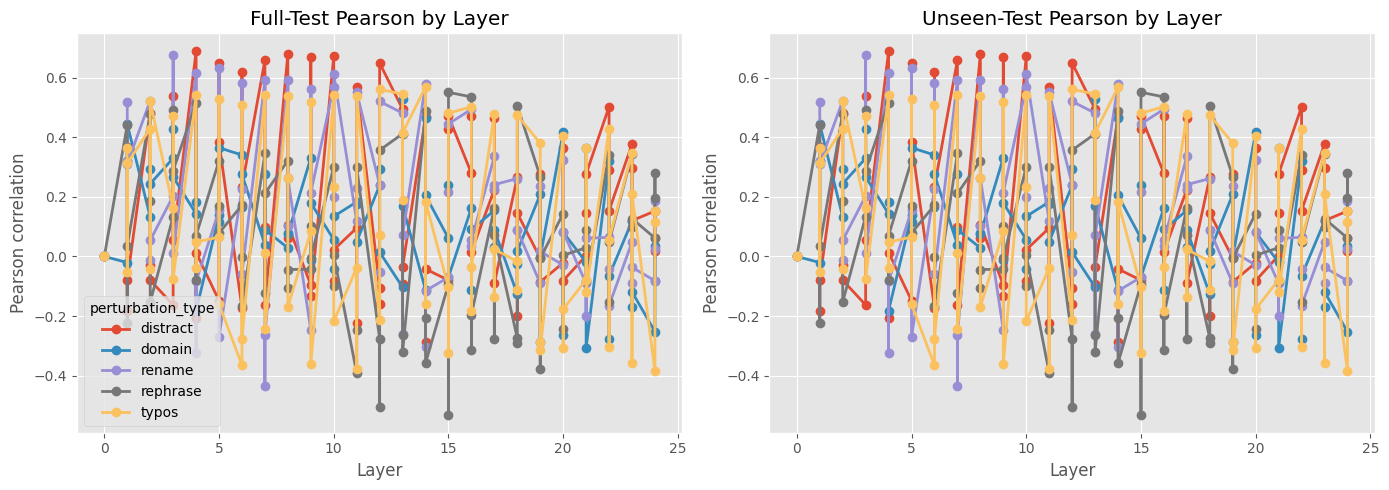

In [86]:
if latest_is_eval_adoption:
    pearson_plot_df = latest_runs.melt(
        id_vars=["layer", "probe_control", "perturbation_type"],
        value_vars=["full_test_pearson", "unseen_test_pearson"],
        var_name="metric",
        value_name="pearson",
    )
    fig = px.line(
        pearson_plot_df,
        x="layer",
        y="pearson",
        color="perturbation_type",
        facet_row="metric",
        facet_col="probe_control",
        markers=True,
        category_orders={"probe_control": ["none", "randomization"], "metric": ["full_test_pearson", "unseen_test_pearson"]},
        title="Pearson by Layer, Control Task, and Perturbation Type",
    )
    fig.for_each_annotation(lambda a: a.update(text=a.text.replace("probe_control=", "control=").replace("metric=", "metric=")))
    fig.update_yaxes(matches=None, title_text="Pearson correlation")
    fig.update_xaxes(title_text="Layer")
    fig.show()
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    for analysis_label, group in latest_runs.groupby("analysis_label"):
        group = group.sort_values("layer")
        axes[0].plot(group["layer"], group["full_test_pearson"], marker="o", linewidth=2, label=analysis_label)
        axes[1].plot(group["layer"], group["unseen_test_pearson"], marker="o", linewidth=2, label=analysis_label)
    axes[0].set_title("Full-Test Pearson by Layer")
    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("Pearson correlation")
    axes[1].set_title("Unseen-Test Pearson by Layer")
    axes[1].set_xlabel("Layer")
    axes[1].set_ylabel("Pearson correlation")
    axes[0].legend(title="analysis_label")
    plt.tight_layout()


In [87]:
if latest_is_eval_adoption:
    fig = px.scatter(
        latest_runs,
        x="layer",
        y="perturbation_type",
        color="full_test_pearson",
        facet_col="probe_control",
        category_orders={"probe_control": ["none", "randomization"]},
        color_continuous_scale="RdBu",
        range_color=[-1, 1],
        title="Full-Test Pearson Heatmap View",
    )
    fig.update_traces(marker={"size": 14, "symbol": "square"})
    fig.for_each_annotation(lambda a: a.update(text=a.text.replace("probe_control=", "control=")))
    fig.update_xaxes(title_text="Layer")
    fig.update_yaxes(title_text="Perturbation type")
    fig.show()
else:
    heatmap_df = latest_runs.pivot(index="analysis_label", columns="layer", values="full_test_pearson").sort_index()
    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(heatmap_df.to_numpy(), aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title("Full-Test Pearson Heatmap")
    ax.set_xlabel("Layer")
    ax.set_ylabel("analysis_label")
    ax.set_xticks(np.arange(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns)
    ax.set_yticks(np.arange(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)
    plt.colorbar(im, ax=ax, label="Pearson correlation")
    plt.tight_layout()


ValueError: Index contains duplicate entries, cannot reshape

In [ ]:
if latest_is_eval_adoption:
    fig = px.line(
        latest_runs.sort_values("layer"),
        x="layer",
        y="full_test_error",
        color="perturbation_type",
        facet_col="probe_control",
        markers=True,
        category_orders={"probe_control": ["none", "randomization"]},
        title="Full-Test Error by Layer, Control Task, and Perturbation Type",
    )
    fig.for_each_annotation(lambda a: a.update(text=a.text.replace("probe_control=", "control=")))
    fig.update_yaxes(title_text="Full-test error")
    fig.update_xaxes(title_text="Layer")
    fig.show()
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    for analysis_label, group in latest_runs.groupby("analysis_label"):
        group = group.sort_values("layer")
        ax.plot(group["layer"], group["full_test_error"], marker="o", linewidth=2, label=analysis_label)
    ax.set_title("Supporting View: Full-Test Error by Layer")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Error")
    ax.legend(title="analysis_label")
    plt.tight_layout()


In [ ]:
if latest_is_eval_adoption:
    top_pairs = best_layers[["probe_control", "perturbation_type", "layer"]].head(6)
    pair_frames = []
    for row in top_pairs.itertuples(index=False):
        subset = latest_preds[(latest_preds["probe_control"] == row.probe_control) & (latest_preds["perturbation_type"] == row.perturbation_type) & (latest_preds["layer"] == row.layer)].copy()
        subset["facet_label"] = f"{row.perturbation_type} | {row.probe_control} | L{row.layer:03d}"
        pair_frames.append(subset)
    scatter_df = pd.concat(pair_frames, ignore_index=True) if pair_frames else pd.DataFrame()
    if not scatter_df.empty:
        fig = px.scatter(
            scatter_df,
            x="label",
            y="pred",
            color="perturbation_type",
            facet_col="probe_control",
            facet_row="facet_label",
            opacity=0.7,
            category_orders={"probe_control": ["none", "randomization"]},
            title="Prediction vs Label for Best Layers",
        )
        fig.for_each_annotation(lambda a: a.update(text=a.text.replace("probe_control=", "control=").replace("facet_label=", "pair=")))
        fig.update_xaxes(title_text="True label")
        fig.update_yaxes(title_text="Prediction")
        fig.show()
else:
    top_labels = best_layers["analysis_label"].tolist()[:4]
    fig, axes = plt.subplots(len(top_labels), 1, figsize=(8, 4 * max(1, len(top_labels))))
    axes = np.atleast_1d(axes)
    for ax, analysis_label in zip(axes, top_labels):
        best_layer = int(best_layers.loc[best_layers["analysis_label"] == analysis_label, "layer"].iloc[0])
        subset = latest_preds[(latest_preds["analysis_label"] == analysis_label) & (latest_preds["layer"] == best_layer)]
        ax.scatter(subset["label"], subset["pred"], alpha=0.7)
        if len(subset) > 1:
            lo = min(subset["label"].min(), subset["pred"].min())
            hi = max(subset["label"].max(), subset["pred"].max())
            ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1)
        ax.set_title(f"{analysis_label} | best layer L{best_layer:03d}")
        ax.set_xlabel("True label")
        ax.set_ylabel("Prediction")
    plt.tight_layout()


In [ ]:
if latest_is_eval_adoption:
    latest_runs.sort_values(["probe_control", "full_test_pearson"], ascending=[True, False])[[
        "probe_control",
        "perturbation_type",
        "layer",
        "full_test_pearson",
        "unseen_test_pearson",
        "full_test_error",
        "unseen_test_error",
        "best_val_pearson",
        "best_val_error",
    ]].head(20)
else:
    latest_runs.sort_values("full_test_pearson", ascending=False)[[
        "analysis_label",
        "layer",
        "full_test_pearson",
        "unseen_test_pearson",
        "full_test_error",
        "unseen_test_error",
        "best_val_pearson",
        "best_val_error",
    ]].head(20)


In [79]:
runs_df

,results_group,probe_name,layer,model_name,encoding,control_task,fold,seed,run_id,status,mtime,metrics_path,epochs_logged,best_val_loss,best_val_error,best_val_pearson,full_test_error,full_test_pearson,unseen_test_error,unseen_test_pearson
0,,aimo-robustness_L000_none,0,qwen-0.5b-instruct,full,NONE,0,42,0,done,1.778155e+09,/Users/tresi/Projects/AIMO-baseline/results/ai...,12,0.703872,NaN,NaN,NaN,NaN,NaN,NaN
1,,aimo-robustness_L000_permutation,0,qwen-0.5b-instruct,full,PERMUTATION,0,42,0,done,1.778155e+09,/Users/tresi/Projects/AIMO-baseline/results/ai...,12,0.703872,NaN,NaN,NaN,NaN,NaN,NaN
2,,aimo-robustness_L000_randomization,0,qwen-0.5b-instruct,full,RANDOMIZATION,0,42,0,done,1.778155e+09,/Users/tresi/Projects/AIMO-baseline/results/ai...,12,0.703872,NaN,NaN,NaN,NaN,NaN,NaN
3,,aimo-robustness_L001_none,1,qwen-0.5b-instruct,full,NONE,0,42,0,done,1.778155e+09,/Users/tresi/Projects/AIMO-baseline/results/ai...,12,0.683127,NaN,NaN,NaN,NaN,NaN,NaN
4,,aimo-robustness_L001_permutation,1,qwen-0.5b-instruct,full,PERMUTATION,0,42,0,done,1.778155e+09,/Users/tresi/Projects/AIMO-baseline/results/ai...,12,0.683127,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,eval_adoption_absolute_accuracy_decay_table_v2,eval-adoption-absolute_accuracy_decay__distrac...,24,qwen2.5-0.5b-instruct,full,DISTRACT,0,42,0,done,1.778694e+09,/Users/tresi/Projects/AIMO-baseline/results/ev...,15,0.192182,0.384363,-0.690390,3.090634,-0.788819,3.090634,-0.788819
372,eval_adoption_absolute_accuracy_decay_table_v2,eval-adoption-absolute_accuracy_decay__domain_...,24,qwen2.5-0.5b-instruct,full,DOMAIN,0,42,0,done,1.778694e+09,/Users/tresi/Projects/AIMO-baseline/results/ev...,21,0.604806,1.515294,0.012666,1.029657,0.641864,1.029657,0.641864
373,eval_adoption_absolute_accuracy_decay_table_v2,eval-adoption-absolute_accuracy_decay__rename_...,24,qwen2.5-0.5b-instruct,full,RENAME,0,42,0,done,1.778694e+09,/Users/tresi/Projects/AIMO-baseline/results/ev...,21,0.326806,0.842555,-0.067732,1.778393,0.028008,1.778393,0.028008
374,eval_adoption_absolute_accuracy_decay_table_v2,eval-adoption-absolute_accuracy_decay__rephras...,24,qwen2.5-0.5b-instruct,full,REPHRASE,0,42,0,done,1.778694e+09,/Users/tresi/Projects/AIMO-baseline/results/ev...,18,0.201593,0.428227,-0.047873,4.018743,0.813809,4.018743,0.813809


## Classic Controls

This section reports the older classification-style control runs when they are present: `NONE` and `RANDOMIZATION`.


In [88]:
classic_controls = ["NONE", "RANDOMIZATION"]
classic_df = runs_df[runs_df["control_task"].isin(classic_controls)].copy()
classic_groups = sorted(classic_df["results_group"].unique()) if not classic_df.empty else []

if classic_df.empty:
    print("No NONE/RANDOMIZATION runs found under results/.")
else:
    print("Classic control result groups:")
    for group in classic_groups:
        print(" -", group or "<root>")

classic_df.head()


Classic control result groups:
 - eval_adoption_absolute_accuracy_decay_aggregated_controls_v2
 - eval_adoption_absolute_accuracy_decay_table_controls_v2


,results_group,probe_name,layer,model_name,encoding,control_task,perturbation_type,sample_size,fold,seed,status,mtime,metrics_path,epochs_logged,best_val_loss,best_val_error,best_val_pearson,full_test_error,full_test_pearson,unseen_test_error,unseen_test_pearson
0,eval_adoption_absolute_accuracy_decay_aggregat...,eval-adoption-absolute_accuracy_decay__distrac...,0,qwen2.5-0.5b-instruct,full,NONE,distract,0,0,42,done,1.778701e+09,/Users/tresi/Projects/AIMO-baseline/results/ev...,21,0.090247,0.180494,0.154098,0.148551,NaN,0.148551,NaN
1,eval_adoption_absolute_accuracy_decay_aggregat...,eval-adoption-absolute_accuracy_decay__domain_...,0,qwen2.5-0.5b-instruct,full,NONE,domain,0,0,42,done,1.778701e+09,/Users/tresi/Projects/AIMO-baseline/results/ev...,21,0.047384,0.094768,0.203095,0.101958,NaN,0.101958,NaN
2,eval_adoption_absolute_accuracy_decay_aggregat...,eval-adoption-absolute_accuracy_decay__rename_...,0,qwen2.5-0.5b-instruct,full,NONE,rename,0,0,42,done,1.778701e+09,/Users/tresi/Projects/AIMO-baseline/results/ev...,21,0.113951,0.227902,0.074715,0.166203,7.140836e-08,0.166203,7.140836e-08
3,eval_adoption_absolute_accuracy_decay_aggregat...,eval-adoption-absolute_accuracy_decay__rephras...,0,qwen2.5-0.5b-instruct,full,NONE,rephrase,0,0,42,done,1.778701e+09,/Users/tresi/Projects/AIMO-baseline/results/ev...,21,0.137471,0.274942,0.264382,0.207150,NaN,0.207150,NaN
4,eval_adoption_absolute_accuracy_decay_aggregat...,eval-adoption-absolute_accuracy_decay__typos__...,0,qwen2.5-0.5b-instruct,full,NONE,typos,0,0,42,done,1.778701e+09,/Users/tresi/Projects/AIMO-baseline/results/ev...,21,0.128712,0.257424,0.082331,0.194399,-1.524030e-07,0.194399,-1.524030e-07


In [89]:
if not classic_df.empty:
    preferred_metrics = [
        "full_test_pearson",
        "unseen_test_pearson",
        "full_test_error",
        "unseen_test_error",
    ]
    fallback_metrics = [
        "full_test_acc",
        "unseen_test_acc",
        "full_test_f1",
        "unseen_test_f1",
    ]
    classic_metric_cols = [
        c for c in preferred_metrics if c in classic_df.columns and classic_df[c].notna().any()
    ]
    if not classic_metric_cols:
        classic_metric_cols = [
            c for c in fallback_metrics if c in classic_df.columns and classic_df[c].notna().any()
        ]
    classic_summary = (
        classic_df.groupby(["results_group", "control_task"])[classic_metric_cols]
        .agg(["mean", "std", "min", "max"])
        .round(4)
    )
    display(classic_summary)


full_test_pearson  \
                                                                              mean   
results_group                                      control_task                      
eval_adoption_absolute_accuracy_decay_aggregate... NONE                     0.3381   
                                                   PERMUTATION             -0.0069   
                                                   RANDOMIZATION            0.0200   
eval_adoption_absolute_accuracy_decay_table_con... NONE                     0.1896   
                                                   PERMUTATION             -0.0181   
                                                   RANDOMIZATION            0.0044   

                                                                          \
                                                                     std   
results_group                                      control_task            
eval_adoption_absolute_accuracy_decay_aggregate... NONE           0.2302   
                                                   PERMUTATION    0.2423   
                                                   RANDOMIZATION  0.1898   
eval_adoption_absolute_accuracy_decay_table_con... NONE           0.5408   
                                                   PERMUTATION    0.3566   
                                                   RANDOMIZATION  0.3639   

                                                                          \
                                                                     min   
results_group                                      control_task            
eval_adoption_absolute_accuracy_decay_aggregate... NONE          -0.2015   
                                                   PERMUTATION   -0.5305   
                                                   RANDOMIZATION -0.3772   
eval_adoption_absolute_accuracy_decay_table_con... NONE          -0.9835   
                                                   PERMUTATION   -0.8206   
                                                   RANDOMIZATION -0.8486   

                                                                          \
                                                                     max   
results_group                                      control_task            
eval_adoption_absolute_accuracy_decay_aggregate... NONE           0.6875   
                                                   PERMUTATION    0.5284   
                                                   RANDOMIZATION  0.6108   
eval_adoption_absolute_accuracy_decay_table_con... NONE           0.9506   
                                                   PERMUTATION    0.8047   
                                                   RANDOMIZATION  0.6561   

                                                                 unseen_test_pearson  \
                                                                                mean   
results_group                                      control_task                        
eval_adoption_absolute_accuracy_decay_aggregate... NONE                       0.3381   
                                                   PERMUTATION               -0.0069   
                                                   RANDOMIZATION              0.0200   
eval_adoption_absolute_accuracy_decay_table_con... NONE                       0.1896   
                                                   PERMUTATION               -0.0181   
                                                   RANDOMIZATION              0.0044   

                                                                          \
                                                                     std   
results_group                                      control_task            
eval_adoption_absolute_accuracy_decay_aggregate... NONE           0.2302   
                                                   PERMUTATION    0.2423   
                                                   RANDOMIZATI

Latest classic control group: eval_adoption_absolute_accuracy_decay_aggregated_controls_v2


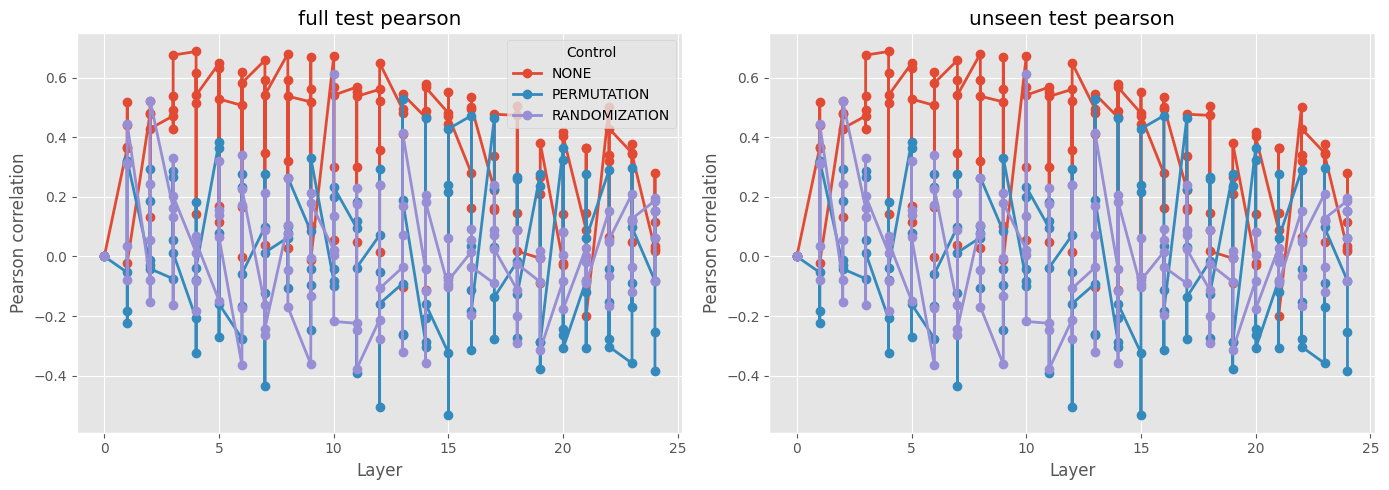

In [90]:
if not classic_df.empty:
    latest_classic_group = classic_df.groupby("results_group")["mtime"].max().sort_values(ascending=False).index[0]
    latest_classic = classic_df[classic_df["results_group"] == latest_classic_group].copy()
    print("Latest classic control group:", latest_classic_group or "<root>")

    pearson_plot_metrics = [
        c for c in ["full_test_pearson", "unseen_test_pearson"]
        if c in latest_classic.columns and latest_classic[c].notna().any()
    ]
    if pearson_plot_metrics:
        fig, axes = plt.subplots(1, len(pearson_plot_metrics), figsize=(7 * len(pearson_plot_metrics), 5), sharex=True)
        axes = np.atleast_1d(axes)
        for ax, metric in zip(axes, pearson_plot_metrics):
            for control_task, group in latest_classic.groupby("control_task"):
                group = group.sort_values("layer")
                ax.plot(group["layer"], group[metric], marker="o", linewidth=2, label=control_task)
            ax.set_title(metric.replace("_", " "))
            ax.set_xlabel("Layer")
            ax.set_ylabel("Pearson correlation")
        axes[0].legend(title="Control")
        plt.tight_layout()
    else:
        fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
        axes = axes.ravel()
        plot_metrics = ["full_test_acc", "full_test_f1", "unseen_test_acc", "unseen_test_f1"]
        for ax, metric in zip(axes, plot_metrics):
            for control_task, group in latest_classic.groupby("control_task"):
                group = group.sort_values("layer")
                ax.plot(group["layer"], group[metric], marker="o", linewidth=2, label=control_task)
            ax.set_title(metric.replace("_", " "))
            ax.set_xlabel("Layer")
            ax.set_ylabel(metric.replace("_", " "))
        axes[0].legend(title="Control")
        plt.tight_layout()


In [91]:
if not classic_df.empty:
    latest_classic_group = classic_df.groupby("results_group")["mtime"].max().sort_values(ascending=False).index[0]
    latest_classic = classic_df[classic_df["results_group"] == latest_classic_group].copy()
    heatmap_metric = "full_test_pearson" if "full_test_pearson" in latest_classic.columns and latest_classic["full_test_pearson"].notna().any() else "full_test_acc"
    heatmap_df = latest_classic.pivot(index="control_task", columns="layer", values=heatmap_metric).sort_index()

    fig, ax = plt.subplots(figsize=(14, 3.5))
    if heatmap_metric.endswith("pearson"):
        im = ax.imshow(heatmap_df.to_numpy(), aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
        color_label = "Pearson correlation"
        title = "Classic Controls: Full-Test Pearson Heatmap"
    else:
        im = ax.imshow(heatmap_df.to_numpy(), aspect="auto", cmap="viridis", vmin=0, vmax=1)
        color_label = heatmap_metric.replace("_", " ")
        title = "Classic Controls: Full-Test Accuracy Heatmap"
    ax.set_title(title)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Control")
    ax.set_xticks(np.arange(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns)
    ax.set_yticks(np.arange(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)
    plt.colorbar(im, ax=ax, label=color_label)
    plt.tight_layout()


ValueError: Index contains duplicate entries, cannot reshape